# Example runs of OAC with different model and species settings

In [1]:
# --- Base OAC RUNS ---
# using numpy 2.3.1 instead of 2.2.6
# had to redownload h5netcdf
import numpy as np
from oac_climate_model import OACClimateModel
from pandas import read_csv
from aviation_climate_simulation import AviationClimateSimulation
from aerocm.utils.functions import plot_simulation_results
from oac.utils.utility import load_species_inventory
from aerocm.climate_models.oac.utils.utility import time_norm_ncdf
import matplotlib.pyplot as plt

In [2]:
# --- Set parameters --- 
start_year = 1940
end_year = 2019
species_inventory = load_species_inventory(start_year,end_year,"OAC")

# Testing "Step" in model settings

In [3]:
model_settings = {"step": 5,
                  "scaling" : "",
                  "weights" : {}
                 }

species_settings = { "CO2" : {"lambda": 0.73, "rf_method" : "Etminan_2016"} , 
                                "H2O" : {"efficacy": 1.14} , 
                                "O3" : {"efficacy":1.37},
                                "PMO" : {"efficacy": 1.37},
                                "CH4" : {"efficacy": 1.14},
                                "Contrails" :{"efficacy": 0.59}
                   }

{'lambda': 0.73, 'rf_method': 'Etminan_2016'}
Saved scaled emissions to oac_inputs\mat_generated_nc_1940.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_1945.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_1950.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_1955.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_1960.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_1965.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_1970.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_1975.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_1980.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_1985.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_1990.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_1995.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_2000.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_2005.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_2010.nc


Saved scaled emissions to oac_inputs\mat_generated_nc_2015.nc
79
TOML file written to oac_run.toml


The computed output is not for scientific purposes until release of our publication.
Amongst others, the climate impact of longer species lifetimes in the stratosphere is not considered.


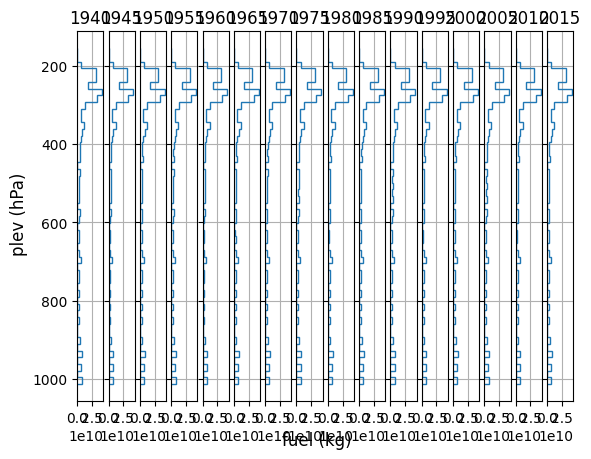

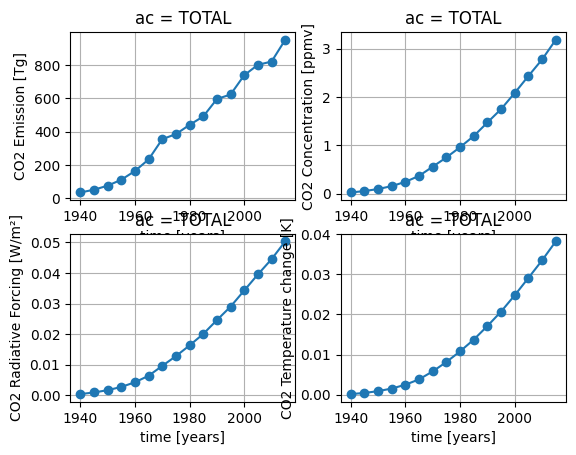

In [4]:
result_co2 = OACClimateModel(start_year, end_year, "CO2", species_inventory["CO2"],species_settings["CO2"], model_settings).run(return_df=True)

{'lambda': 0.73, 'rf_method': 'Etminan_2016'}
Saved scaled emissions to oac_inputs\mat_generated_nc_1940.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_1945.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_1950.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_1955.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_1960.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_1965.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_1970.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_1975.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_1980.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_1985.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_1990.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_1995.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_2000.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_2005.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_2010.nc
Saved scaled emissions t

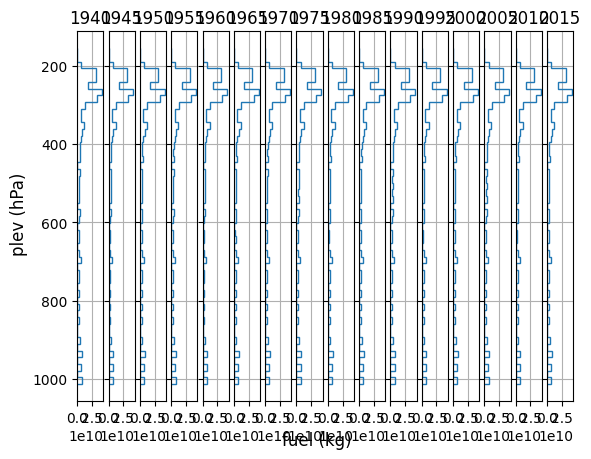

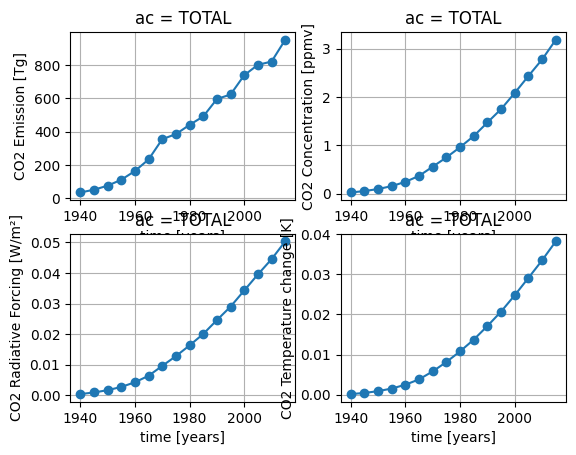

{'efficacy': 0.59}
Saved scaled emissions to oac_inputs\mat_generated_nc_1940.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_1945.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_1950.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_1955.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_1960.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_1965.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_1970.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_1975.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_1980.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_1985.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_1990.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_1995.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_2000.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_2005.nc
Saved scaled emissions to oac_inputs\mat_generated_nc_2010.nc
Saved scaled emissions to oac_inputs\mat_generated_

PermissionError: [WinError 32] Le processus ne peut pas accéder au fichier car ce fichier est utilisé par un autre processus: 'oac_results/gen_1940s.nc'

In [5]:
climate_model = 'OAC'
results_full_interpolation = AviationClimateSimulation(climate_model, start_year, end_year,species_inventory,species_settings, model_settings).run(return_xr = True)

In [ ]:
results_full_interpolation

In [ ]:
plot_simulation_results(results_full_interpolation, data_var="temperature", species=["Contrails"], stacked=False)

# Testing time norm 

In [ ]:
model_settings = {"step" : 1,
                  "scaling" : "norm"
                 }
species_settings = { "CO2" :{"ratio_erf_rf":  1.0} , 
                                      "Contrails" :{"ratio_erf_rf": 1.0} ,
                                      "NOx" : {"ratio_erf_rf": 1.0},
                                      "H2O" : {"ratio_erf_rf": 1.0} , 

    }

In [ ]:
climate_model = 'OAC'
results_full = AviationClimateSimulation(climate_model, start_year, end_year,species_inventory,species_settings, model_settings).run(return_xr = True)

In [ ]:
results_full

In [ ]:
results_full_interpolation

In [ ]:
print("NORMALISATION RESULTS")
plot_simulation_results(results_full, data_var="temperature", species=["CO2","Contrails"], stacked=False)

plot_simulation_results(results_full_interpolation, data_var="temperature", species=["CO2", "Contrails"], stacked=False)

# Efficacy

In [ ]:
species_settings2 = { "CO2" : {"lambda": 3.73} , 
                                "H2O" : {"efficacy": 1.14} , 
                                "O3" : {"efficacy":1.37},
                                "PMO" : {"efficacy": 1.37},
                                "CH4" : {"efficacy": 1.14},
                                "Contrails" :{"efficacy": 2.59} 
                                      
    }

model_settings = {"step" : 1,
                  "scaling" : "norm"
                 }

In [ ]:
climate_model = 'OAC'
results_co2_373 = AviationClimateSimulation(climate_model, start_year, end_year,species_inventory,species_settings2, model_settings).run(return_xr = True)

In [ ]:
results_cont_std

In [ ]:
results_cont_ext

In [ ]:
plot_simulation_results(results_co2_373, data_var="temperature", species=["CO2"], stacked=False)
#plot_simulation_results(results_cont_ext, data_var="temperature", species=["Contrails"], stacked=False)

In [ ]:
plot_simulation_results(results_full, data_var="temperature", species=["Contrails"], stacked=False)

# Weighted runs

In [ ]:
species_settings2 = { "CO2" : {"lambda": 0.73} , 
                                "H2O" : {"efficacy": 1.14} , 
                                "O3" : {"efficacy":1.37},
                                "PMO" : {"efficacy": 1.37},
                                "CH4" : {"efficacy": 1.14},
                                "Contrails" :{"efficacy": 0.59} 
                                      
    }

model_settings = {"step" : 1,
                  "scaling" : "",
                  "weights" : {"North America": 1,
                       "Atlantic region": 1.0,
                       "South America": 1.0,
                       "Pacific": 1.0,
                       "Far North": 1.0,
                       "Europe": 1,
                       "Africa and Middle East": 1.0,
                       "Asia": 1.0,
                       "Oceania": 1.0}
                 }
model_settings = {"step" : 1,
                  "scaling" : "", 
                  "weights" : {}
                 }

In [ ]:
climate_model = 'OAC'
results = AviationClimateSimulation(climate_model, start_year, end_year,species_inventory,species_settings2, model_settings).run(return_xr = True)

In [ ]:
plot_simulation_results(results, data_var="temperature", species=["Contrails"],title = "contrails",stacked=False)
plot_simulation_results(results, data_var="temperature", species=["CO2"],title = "CO2",stacked=False)

In [ ]:
results_cont_w = results_co2_373

In [ ]:
plot_simulation_results(results_full, data_var="temperature", species=["Contrails"],title = "unweighted contrails",stacked=False)
plot_simulation_results(results_cont_w, data_var="temperature", species=["Contrails"],title = "weighted contrails",stacked=False)

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt

In [ ]:
contrails_temp_uw = results_full["temperature"].sel(species="Contrails")
contrails_temp_w = results_cont_w["temperature"].sel(species="Contrails")

In [ ]:
plt.figure()
plt.plot(contrails_temp_uw['year'], contrails_temp_uw, label='Unweighted')
plt.plot(contrails_temp_w['year'], contrails_temp_w, label='Weighted')
plt.xlabel("Year")
plt.ylabel("Temperature change (K)")
plt.title("Contrails Temperature Impact")
plt.legend()
plt.grid(True)
plt.show()

# Different RF methods 
avaliable co2 rf methods - Etminan_2016 (default), IPCC_2001_1, IPCC_2001_2 and IPCC_2001_3.

In [ ]:
species_settings2 = { "CO2" : {"lambda": 0.73, "rf_method" : "IPCC_2001_3"} , 
                                "H2O" : {"efficacy": 1.14} , 
                                "O3" : {"efficacy":1.37},
                                "PMO" : {"efficacy": 1.37},
                                "CH4" : {"efficacy": 1.14},
                                "Contrails" :{"efficacy": 0.59} 
                                      
    }

model_settings = {"step" : 1,
                  "scaling" : "",
                  "weights" : {}
                 }

In [ ]:
result_co2_ipcc_2001_3 = OpenAirClim(start_year, end_year, "CO2", species_inventory["CO2"],species_settings2["CO2"], model_settings).run(return_df=True)

In [ ]:
plt.figure()

#plt.plot(result_co2_ipcc_2001_1.index, result_co2_ipcc_2001_1["radiative_forcing"], label="IPCC_2001_1")
#plt.plot(result_co2_ipcc_2001_2.index, result_co2_ipcc_2001_2["radiative_forcing"], label="Run 2")
plt.plot(result_co2_ipcc_2001_3.index, result_co2_ipcc_2001_3["radiative_forcing"], label="Run 3")
plt.plot(result_co2_etminan.index, result_co2_etminan["radiative_forcing"], label="Run 4")

plt.xlabel("Year")
plt.ylabel("Radiative forcing")
plt.legend()
plt.grid()
plt.show()